# Sale prices King County, prediction model

# Objectives

# Methodology

# Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np

1. Load Dataset

In [23]:
#Data importing 
df = pd.read_csv("C:/Users/anmnu/DSML/Week5/Project/ML_House_Data/data/housing.csv")

2. Explore the data

In [24]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

# Data description 
- id :- It is the unique numeric number assigned to each house being sold.
- date :- It is the date on which the house was sold out.
- price:- It is the price of house which we have to predict so this is our target variable and aprat from it are our features.
- bedrooms :- It determines number of bedrooms in a house.
- bathrooms :- It determines number of bathrooms in a bedroom of a house.
- sqft_living :- It is the measurement variable which determines the measurement of house in square foot.
- sqft_lot : It is also the measurement variable which determines square foot of the lot.
- floors: It determines total floors means levels of house.
- waterfront : This feature determines whether a house has a view to waterfront 0 means no 1 means yes.
- view : This feature determines whether a house has been viewed or not 0 means no 1 means yes.
- condition : It determines the overall condition of a house on a scale of 1 to 5.
- grade : It determines the overall grade given to the housing unit, based on King County grading system on a scale of 1 to 11
- sqft_above : It determines square footage of house apart from basement.
- sqft_basement : It determines square footage of the basement of the house.
- yr_built : It detrmines the date of building of the house.
- yr_renovated : It detrmines year of renovation of house.
- zipcode : It determines the zipcode of the location of the house.
- lat : It determines the latitude of the location of the house.
- long : It determines the longitude of the location of the house.
- sqft_living15 : Living room area in 2015(implies-- some renovations)
- sqft_lot15 : lotSize area in 2015(implies-- some renovations)

3. Data cleaning

In [6]:
# Missing data
df.isna().sum()


id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [7]:
# Percentage of 0 values in dataset
(df == 0).sum()/len(df)*100

id                0.000000
date              0.000000
price             0.000000
bedrooms          0.060149
bathrooms         0.046268
sqft_living       0.000000
sqft_lot          0.000000
floors            0.000000
waterfront       99.245824
view             90.172581
condition         0.000000
grade             0.000000
sqft_above        0.000000
sqft_basement    60.731967
yr_built          0.000000
yr_renovated     95.771064
zipcode           0.000000
lat               0.000000
long              0.000000
sqft_living15     0.000000
sqft_lot15        0.000000
dtype: float64

In [26]:
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df_clean = df.drop("date", axis = 1)
df_clean["price"] = df_clean.pop("price")
df_clean

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,price
0,7129300520,3,1.00,1180,5650,1.0,0,0,3,7,...,0,98178,47.5112,-122.257,1340,5650,2014,10,13,221900.0
1,6414100192,3,2.25,2570,7242,2.0,0,0,3,7,...,1991,98125,47.7210,-122.319,1690,7639,2014,12,9,538000.0
2,5631500400,2,1.00,770,10000,1.0,0,0,3,6,...,0,98028,47.7379,-122.233,2720,8062,2015,2,25,180000.0
3,2487200875,4,3.00,1960,5000,1.0,0,0,5,7,...,0,98136,47.5208,-122.393,1360,5000,2014,12,9,604000.0
4,1954400510,3,2.00,1680,8080,1.0,0,0,3,8,...,0,98074,47.6168,-122.045,1800,7503,2015,2,18,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,3,2.50,1530,1131,3.0,0,0,3,8,...,0,98103,47.6993,-122.346,1530,1509,2014,5,21,360000.0
21609,6600060120,4,2.50,2310,5813,2.0,0,0,3,8,...,0,98146,47.5107,-122.362,1830,7200,2015,2,23,400000.0
21610,1523300141,2,0.75,1020,1350,2.0,0,0,3,7,...,0,98144,47.5944,-122.299,1020,2007,2014,6,23,402101.0
21611,291310100,3,2.50,1600,2388,2.0,0,0,3,8,...,0,98027,47.5345,-122.069,1410,1287,2015,1,16,400000.0


In [29]:
#Selecting features and target variables
features = df_clean.drop("price", axis = 1)
target = df_clean["price"]

In [37]:
# Taking continuous as features

num_features= ['id', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15', 'year', 'month', 'day']



X_num_features = df_clean[num_features]
target = df_clean["price"]
X_train, X_test, y_train, y_test = train_test_split(X_num_features, target, test_size= 0.2, random_state= 42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

129224.97770325911
0.6827258518596898


In [39]:
# KNN numerical 

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Features & target
X = df_clean.drop(['price'], axis=1)
y = df_clean['price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline (ALL IN ONE BOX)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))


101043.12690261393
0.766425479693517


In [30]:
# Train and test split 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size= 0.2, random_state= 42)

In [31]:
# Baseline modeling Linear Regression 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pred = model.predict(X_test)
y_pred

array([ 460523.13645657,  737695.67105546, 1225230.40955363, ...,
        418780.25144894,  618614.68150915,  441337.10805686],
      shape=(4323,))

In [36]:
from sklearn.metrics import mean_absolute_error, r2_score 
print(mean_absolute_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

126912.34372601773
0.7027182400021401


## Categorical variables 
- Waterfront: 0 or 1 
- zipcode

## Numerical Variables 
- View: 0 to 4
- conditions : 1 to 5 
- grade: 1 to 11

In [9]:
df_clean.duplicated().sum()

np.int64(0)

- No missing data 
- No duplicated rows

4. Split 

In [10]:
#Selecting features and target variables
X = df_clean.drop("price", axis = 1)
y = df_clean["price"]

In [ ]:
X = df.drop("price", axis = 1)
y = df["price"]

In [11]:
# Train and test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

## 5. Correlation check between variables

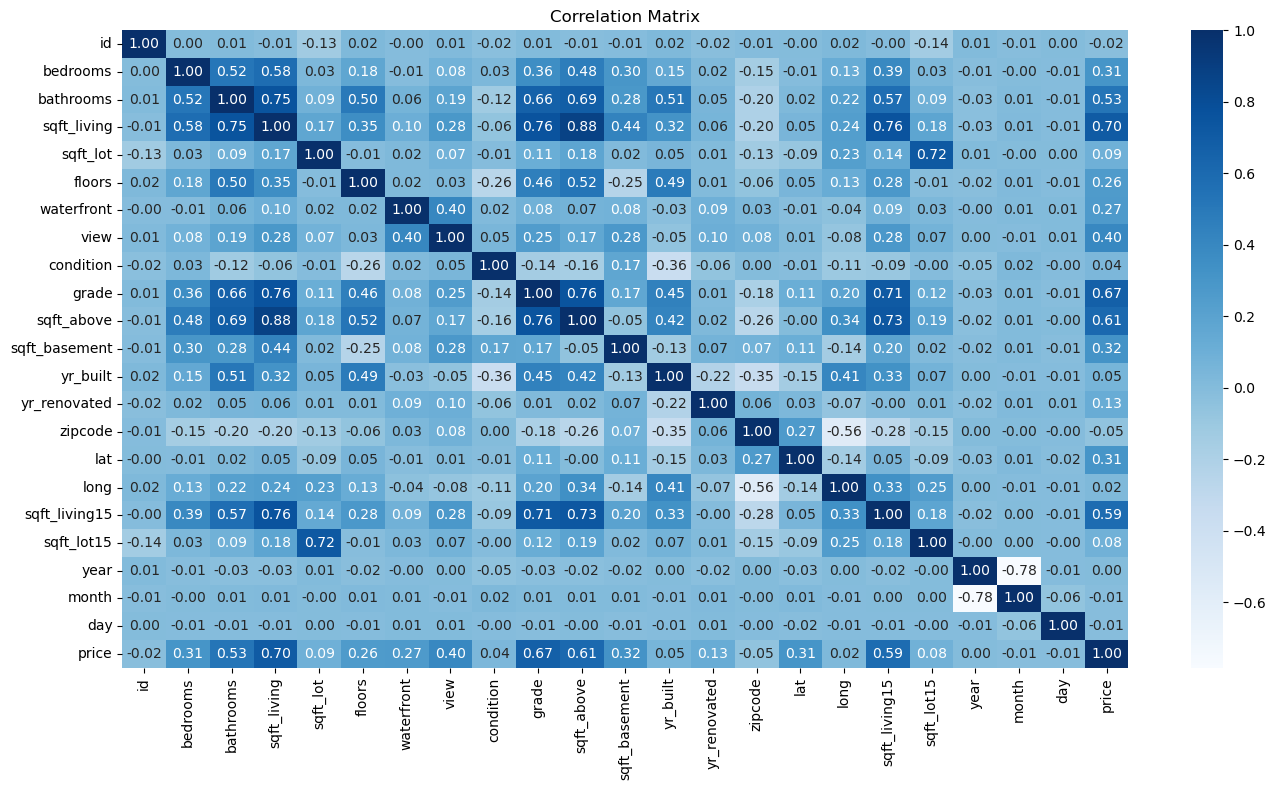

In [12]:
import numpy as np
plt.figure(figsize=(14,8))
#Creating a mask for the upper triangle

threshold = 0.7
mask = np.abs(df_clean.corr()) < threshold
sns.heatmap(df_clean.corr(), annot=True,fmt='.2f', cmap='Blues', xticklabels=df_clean.columns, yticklabels=df_clean.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

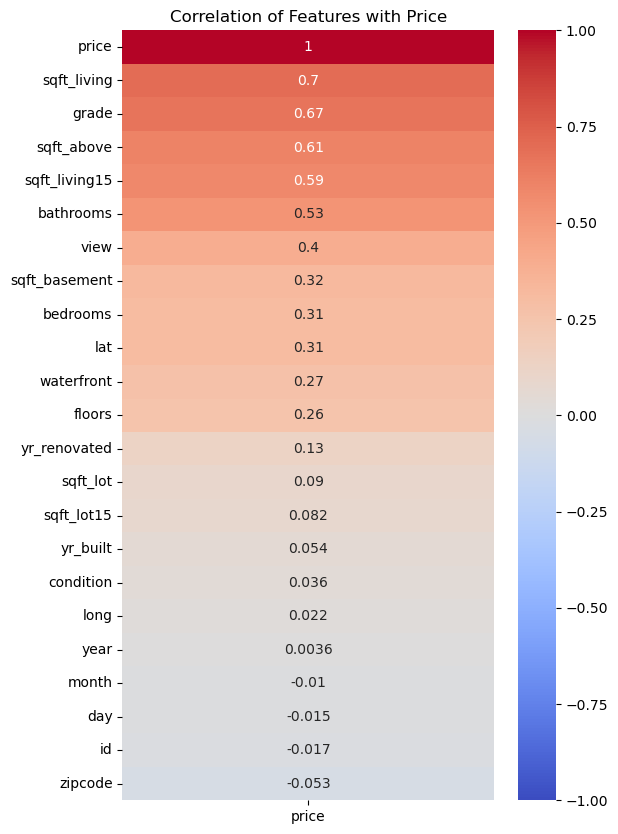

In [13]:
# Compute correlations with target
corr_with_price = df_clean.corr(numeric_only=True)[['price']].sort_values(by='price', ascending=False)

plt.figure(figsize=(6,10))
sns.heatmap(corr_with_price, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title("Correlation of Features with Price")
plt.show()

*Comments*

- Feature correlation: Highest correlation is observed between variables that refer to the sqft property and grade. 
- Target-Feature correlation: The features that correlate best to the target are those related to sqft of the property (sqft_above, sqft_living, sqft_living15 for those renovated in 2015), grade and number of bathrooms.
- The less correlation is found amongst zipcode, and id. Both parameters are not continuous, which is why the expected colinearity is low.  

6. Handle categorical variables. 

Considering year of renovation as a binary variable. 

In [14]:
#Converting to 0 or 1 if renovated
df_clean["renovated"] = df_clean["yr_renovated"].apply(lambda x: 1 if x != 0 else x)


In [15]:
#Dropping ID 
df_clean = df_clean.drop(["id", "lat","long","zipcode"], axis=1)


In [21]:
df_clean

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,year,month,day,price,renovated
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650,2014,10,13,221900.0,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,2014,12,9,538000.0,1
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062,2015,2,25,180000.0,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000,2014,12,9,604000.0,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503,2015,2,18,510000.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,1530,1509,2014,5,21,360000.0,0
21609,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,1830,7200,2015,2,23,400000.0,0
21610,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,1020,2007,2014,6,23,402101.0,0
21611,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,1410,1287,2015,1,16,400000.0,0


In [ ]:
for feature in features:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=dataframe,
        x=feature,
        y=target,
        alpha=0.6
    )

            plt.title(f"{feature} vs {target}")
            plt.xlabel(feature)
            plt.ylabel(target)
            plt.tight_layout()

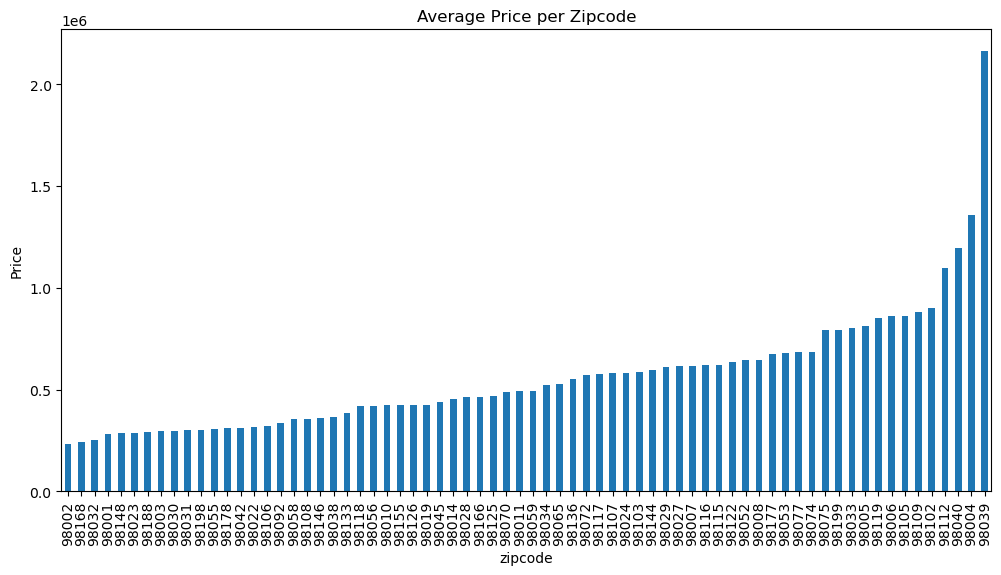

In [17]:
avg_price = df.groupby('zipcode')['price'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')

plt.title("Average Price per Zipcode")
plt.ylabel("Price")
plt.show()

In [18]:
zip_mean = df.groupby('zipcode')['price'].mean()
zip_category = pd.qcut(
    zip_mean,
    q = 3,
    labels = [1, 2, 3] # 1 lowest, 3 = highest
)
df['zipcode_category'] = df['zipcode'].map(zip_category)
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,year,month,day,zipcode_category
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,98178,47.5112,-122.257,1340,5650,2014,10,13,1
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,1991,98125,47.7210,-122.319,1690,7639,2014,12,9,2
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0,98028,47.7379,-122.233,2720,8062,2015,2,25,2
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,0,98136,47.5208,-122.393,1360,5000,2014,12,9,2
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,98074,47.6168,-122.045,1800,7503,2015,2,18,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,0,98103,47.6993,-122.346,1530,1509,2014,5,21,2
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,0,98146,47.5107,-122.362,1830,7200,2015,2,23,1
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,0,98144,47.5944,-122.299,1020,2007,2014,6,23,2
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,0,98027,47.5345,-122.069,1410,1287,2015,1,16,2


In [19]:
df['zipcode_category'].value_counts()

zipcode_category
1    7662
2    7132
3    6819
Name: count, dtype: int64

C:\Users\anmnu\AppData\Local\Temp\ipykernel_8388\2059443409.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price = df.groupby('zipcode_category')['price'].mean().sort_values()


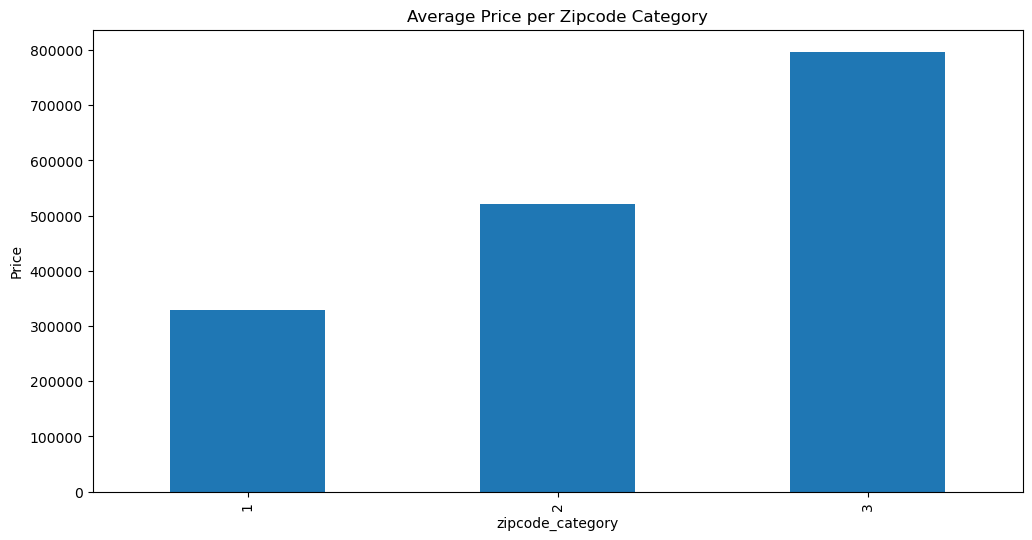

In [20]:
avg_price = df.groupby('zipcode_category')['price'].mean().sort_values()

plt.figure(figsize=(12,6))
avg_price.plot(kind='bar')

plt.title("Average Price per Zipcode Category")
plt.ylabel("Price")
plt.show()